In [1]:
import mne

In [ ]:
raw = mne.io.read_raw_eeglab(
    "../data/sub-03_task-ImaginedEmotion_eeg.set",
    preload=True
)
events, event_id = mne.events_from_annotations(raw)

Reading /Users/jranji/Desktop/ML Project/Code/Part 2/../data/sub-03_task-ImaginedEmotion_eeg.fdt
Reading 0 ... 1251327  =      0.000 ...  4887.996 secs...
Used Annotations descriptions: [np.str_('ExitThankYou'), np.str_('FeelingItInstructionsButton'), np.str_('ImaginationSuggestions'), np.str_('InstructionsForEnding'), np.str_('anger'), np.str_('awe'), np.str_('compassion'), np.str_('content'), np.str_('disgust'), np.str_('enter'), np.str_('excite'), np.str_('exit'), np.str_('fear'), np.str_('frustration'), np.str_('grief'), np.str_('happy'), np.str_('jealousy'), np.str_('joy'), np.str_('love'), np.str_('postbase'), np.str_('postbase_instruct'), np.str_('prebase'), np.str_('prebase_instruct'), np.str_('press'), np.str_('press1'), np.str_('relax'), np.str_('relief'), np.str_('sad')]


In [5]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: A4, A5, A6, A7, A12, A13, A14, A18, A19, A20, A21, A30, A31, B1, ...
 chs: 134 EEG
 custom_ref_applied: False
 dig: 137 items (3 Cardinal, 134 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 134
 projs: []
 sfreq: 256.0 Hz
>

In [17]:
raw.duration

np.float64(4888.0)

In [19]:
raw.filter(1.0, 45.0, fir_window='hamming')
raw.notch_filter(freqs=60)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge

<RawEEGLAB | sub-03_task-ImaginedEmotion_eeg.fdt, 134 x 1251328 (4888.0 s), ~1.25 GiB, data loaded>

In [22]:
tmin, tmax = 0.0, 4.0 #Four second intervals
epochs = mne.Epochs(
    raw, events,
    event_id=event_id,
    tmin=tmin, tmax=tmax,
    baseline=None,
    preload=True,
    reject_by_annotation=True
)


Not setting metadata
94 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 94 events and 1025 original time points ...
0 bad epochs dropped


In [24]:
epochs.get_data().shape

(94, 134, 1025)

In [25]:
raw.get_data().shape

(134, 1251328)

In [ ]:
sample_freq = raw.info["sfreq"]


256.0

Reading /Users/jranji/Desktop/ML Project/Code/Part 2/../data/sub-03_task-ImaginedEmotion_eeg.fdt
Reading 0 ... 1251327  =      0.000 ...  4887.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple

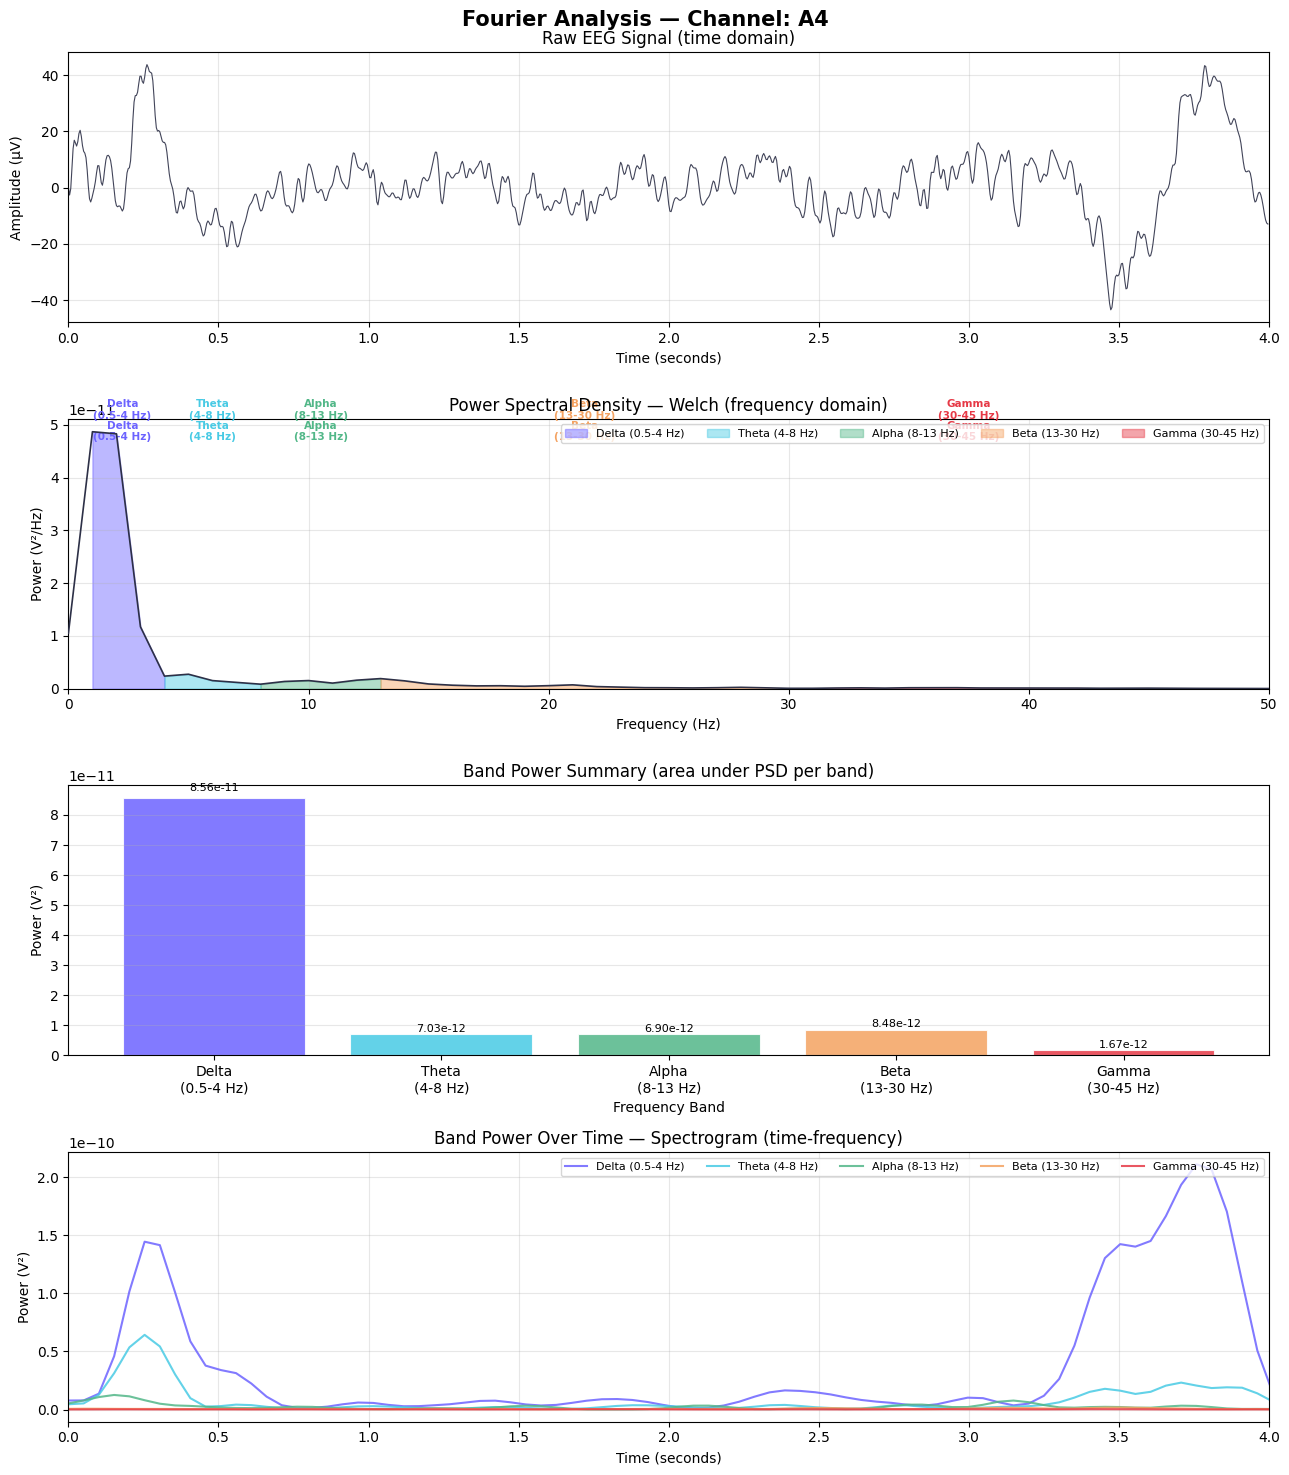

Saved plot to eeg_fourier_plot.png

Band powers for channel 'A4' (first 4 seconds):
  Delta (0.5-4 Hz)          8.5562e-11 V²
  Theta (4-8 Hz)            7.0281e-12 V²
  Alpha (8-13 Hz)           6.9030e-12 V²
  Beta (13-30 Hz)           8.4842e-12 V²
  Gamma (30-45 Hz)          1.6707e-12 V²


In [38]:
"""
Fourier Transform on EEG data — decompose one channel into its frequency components
and visualize both the raw signal and its power spectrum with band annotations.
"""
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy.signal import welch

# ── 1. LOAD ───────────────────────────────────────────────────────────────────

raw = mne.io.read_raw_eeglab(
    "../data/sub-03_task-ImaginedEmotion_eeg.set",
    preload=True
)
raw.filter(1.0, 45.0, fir_window='hamming')
raw.notch_filter(freqs=60)

sfreq = raw.info['sfreq']
ch_names = raw.ch_names

# ── 2. GRAB A SINGLE CHANNEL SNIPPET ─────────────────────────────────────────
# We'll just take the first 4 seconds of channel 0 as an example epoch.
# Swap ch_names[0] for any channel name you prefer, e.g. 'Fz', 'Cz', etc.

channel_name = ch_names[0]
channel_idx  = 0
n_samples    = int(4 * sfreq)   # 4 seconds worth of samples

signal_1d = raw.get_data(picks=[channel_idx])[0, :n_samples]
time      = np.arange(n_samples) / sfreq   # time axis in seconds

# ── 3. FOURIER TRANSFORM ──────────────────────────────────────────────────────
# np.fft.rfft gives us the complex frequency components.
# np.abs squared gives us the power at each frequency.

fft_vals  = np.fft.rfft(signal_1d)
fft_freqs = np.fft.rfftfreq(n_samples, d=1.0 / sfreq)
fft_power = (np.abs(fft_vals) ** 2) / n_samples   # raw FFT power

# Welch's method (smoother, averaged version — what we use for band power)
welch_freqs, welch_psd = welch(signal_1d, sfreq, nperseg=256)

# ── 4. BAND POWER (area under PSD curve per band) ────────────────────────────

BANDS = {
    'Delta\n(0.5-4 Hz)':  (0.5,  4,  '#6C63FF'),
    'Theta\n(4-8 Hz)':    (4,    8,  '#48CAE4'),
    'Alpha\n(8-13 Hz)':   (8,   13,  '#52B788'),
    'Beta\n(13-30 Hz)':   (13,  30,  '#F4A261'),
    'Gamma\n(30-45 Hz)':  (30,  45,  '#E63946'),
}

band_powers = {}
for band, (fmin, fmax, _) in BANDS.items():
    idx = np.logical_and(welch_freqs >= fmin, welch_freqs <= fmax)
    band_powers[band] = np.trapezoid(welch_psd[idx], welch_freqs[idx])

# ── 5. PLOT ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(13, 15))
fig.suptitle(f'Fourier Analysis — Channel: {channel_name}', fontsize=15, fontweight='bold', y=0.98)

# --- Panel 1: Raw voltage time series ---
ax1 = axes[0]
ax1.plot(time, signal_1d * 1e6, color='#2D3047', linewidth=0.8, alpha=0.9)
ax1.set_title('Raw EEG Signal (time domain)', fontsize=12)
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Amplitude (µV)')
ax1.set_xlim([0, 4])
ax1.grid(True, alpha=0.3)

# --- Panel 2: Power spectrum with band shading (Welch) ---
ax2 = axes[1]
ax2.plot(welch_freqs, welch_psd, color='#2D3047', linewidth=1.2, zorder=5)

for band, (fmin, fmax, color) in BANDS.items():
    idx = np.logical_and(welch_freqs >= fmin, welch_freqs <= fmax)
    ax2.fill_between(welch_freqs[idx], welch_psd[idx], alpha=0.45, color=color, label=band.replace('\n', ' '))
    # Annotate band name in the middle
    mid_freq = (fmin + fmax) / 2
    ax2.text(mid_freq, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 0 else 1,
             band, ha='center', fontsize=7.5, color=color, fontweight='bold')

ax2.set_title('Power Spectral Density — Welch (frequency domain)', fontsize=12)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (V²/Hz)')
ax2.set_xlim([0, 50])
ax2.legend(loc='upper right', fontsize=8, ncol=5)
ax2.grid(True, alpha=0.3)

# Re-annotate after ylim is established
ax2.set_ylim(bottom=0)
for band, (fmin, fmax, color) in BANDS.items():
    mid_freq = (fmin + fmax) / 2
    ymax = ax2.get_ylim()[1]
    ax2.text(mid_freq, ymax * 0.92, band, ha='center', fontsize=7.5,
             color=color, fontweight='bold')

# --- Panel 3: Band power bar chart ---
ax3 = axes[2]
band_labels = [b.replace('\n', '\n') for b in BANDS.keys()]
colors      = [v[2] for v in BANDS.values()]
powers      = list(band_powers.values())

bars = ax3.bar(band_labels, powers, color=colors, edgecolor='white', linewidth=0.8, alpha=0.85)
ax3.set_title('Band Power Summary (area under PSD per band)', fontsize=12)
ax3.set_xlabel('Frequency Band')
ax3.set_ylabel('Power (V²)')
ax3.grid(True, axis='y', alpha=0.3)

# Label each bar with its value
for bar, power in zip(bars, powers):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() * 1.02,
             f'{power:.2e}', ha='center', va='bottom', fontsize=8)
    

ax4 = axes[3]

# Sliding window FFT: nperseg controls window size, noverlap controls smoothness
window_sec = 0.5          # 500ms window
hop_sec    = 0.05         # 50ms hop (step between windows)
nperseg    = int(window_sec * sfreq)
noverlap   = int((window_sec - hop_sec) * sfreq)

stft_freqs, stft_times, Zxx = signal.stft(
   signal_1d, fs=sfreq, nperseg=nperseg, noverlap=noverlap
)
power_over_time = np.abs(Zxx) ** 2   # shape: (n_freqs, n_time_windows)

# For each time window, sum power within each band
for band, (fmin, fmax, color) in BANDS.items():
   idx = np.logical_and(stft_freqs >= fmin, stft_freqs <= fmax)
   band_power_t = power_over_time[idx, :].mean(axis=0)
   ax4.plot(stft_times, band_power_t, color=color, linewidth=1.5,
             label=band.replace('\n', ' '), alpha=0.85)

ax4.set_title('Band Power Over Time — Spectrogram (time-frequency)', fontsize=12)
ax4.set_xlabel('Time (seconds)')
ax4.set_ylabel('Power (V²)')
ax4.set_xlim([0, 4])
ax4.legend(loc='upper right', fontsize=8, ncol=5)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('eeg_fourier_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot to eeg_fourier_plot.png")

# ── 6. PRINT BAND POWERS ─────────────────────────────────────────────────────

print(f"\nBand powers for channel '{channel_name}' (first 4 seconds):")
for band, power in band_powers.items():
    print(f"  {band.replace(chr(10), ' '):<25} {power:.4e} V²")


